In [2]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from transformers import CLIPProcessor, CLIPModel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [5]:
DATA_DIR = Path("two_class_cifar")   # 按你的 notebook 实际位置调整
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR exists:", DATA_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_DIR exists: True
OUTPUT_DIR: /home/amyliu/Desktop/GR/outputs


In [6]:
classes = ["cat", "dog"]

image_paths = []
labels = []

for cls in classes:
    class_dir = DATA_DIR / cls
    files = sorted(class_dir.glob("*.png"))
    
    for f in files:
        image_paths.append(f)
        labels.append(cls)

print("Total images:", len(image_paths))
print("First 5 paths:")
for p, l in list(zip(image_paths, labels))[:5]:
    print(l, p)

Total images: 40
First 5 paths:
cat two_class_cifar/cat/cat_000.png
cat two_class_cifar/cat/cat_001.png
cat two_class_cifar/cat/cat_002.png
cat two_class_cifar/cat/cat_003.png
cat two_class_cifar/cat/cat_004.png


In [7]:
model_name = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device)
model.eval()

print("CLIP loaded:", model_name)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded: openai/clip-vit-base-patch32


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [ ]:
root = Path("./data")  
output_root = Path("./two_class_cifar")  
output_root.mkdir(parents=True, exist_ok=True)

In [11]:
from PIL import Image
import torch

test_img = Image.open(image_paths[0]).convert("RGB")

inputs = processor(images=test_img, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():
    vision_outputs = model.vision_model(pixel_values=pixel_values)
    pooled_output = vision_outputs.pooler_output          # [1, hidden_dim]
    features = model.visual_projection(pooled_output)     # [1, 512]

features = features / features.norm(dim=-1, keepdim=True)

print("Feature shape:", features.shape)
print(features[0, :10])

Feature shape: torch.Size([1, 512])
tensor([ 0.0122, -0.0074, -0.0355,  0.0156,  0.0138, -0.0333,  0.0122,  0.0612,
         0.0133,  0.0081], device='cuda:0')


In [12]:
all_embeddings = []
all_filenames = []
all_labels = []

for img_path, label in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        emb = model.visual_projection(pooled_output)

    emb = emb / emb.norm(dim=-1, keepdim=True)

    all_embeddings.append(emb.cpu().numpy().squeeze())
    all_filenames.append(img_path.name)
    all_labels.append(label)

all_embeddings = np.array(all_embeddings)

print("Embeddings shape:", all_embeddings.shape)
print("First 3 labels:", all_labels[:3])
print("First 3 filenames:", all_filenames[:3])

100%|██████████| 40/40 [00:00<00:00, 206.50it/s]

Embeddings shape: (40, 512)
First 3 labels: ['cat', 'cat', 'cat']
First 3 filenames: ['cat_000.png', 'cat_001.png', 'cat_002.png']


In [13]:
np.save(OUTPUT_DIR / "clip_embeddings_cat_dog.npy", all_embeddings)

df = pd.DataFrame({
    "filename": all_filenames,
    "label": all_labels
})
df.to_csv(OUTPUT_DIR / "clip_metadata_cat_dog.csv", index=False)

print("Saved embeddings to:", OUTPUT_DIR / "clip_embeddings_cat_dog.npy")
print("Saved metadata to:", OUTPUT_DIR / "clip_metadata_cat_dog.csv")

Saved embeddings to: outputs/clip_embeddings_cat_dog.npy
Saved metadata to: outputs/clip_metadata_cat_dog.csv


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

embeddings = np.load("outputs/clip_embeddings_cat_dog.npy")
metadata = pd.read_csv("outputs/clip_metadata_cat_dog.csv")

print("Embeddings shape:", embeddings.shape)
print(metadata.head())

Embeddings shape: (40, 512)
      filename label
0  cat_000.png   cat
1  cat_001.png   cat
2  cat_002.png   cat
3  cat_003.png   cat
4  cat_004.png   cat


In [15]:
sim_matrix = cosine_similarity(embeddings)

print("Similarity matrix shape:", sim_matrix.shape)
print(sim_matrix[:5, :5])

Similarity matrix shape: (40, 40)
[[0.9999996  0.91940266 0.88270515 0.9154826  0.93291354]
 [0.91940266 1.0000002  0.86098385 0.88995695 0.9386075 ]
 [0.88270515 0.86098385 1.0000001  0.8813136  0.8689396 ]
 [0.9154826  0.88995695 0.8813136  1.0000001  0.9076283 ]
 [0.93291354 0.9386075  0.8689396  0.9076283  0.99999964]]


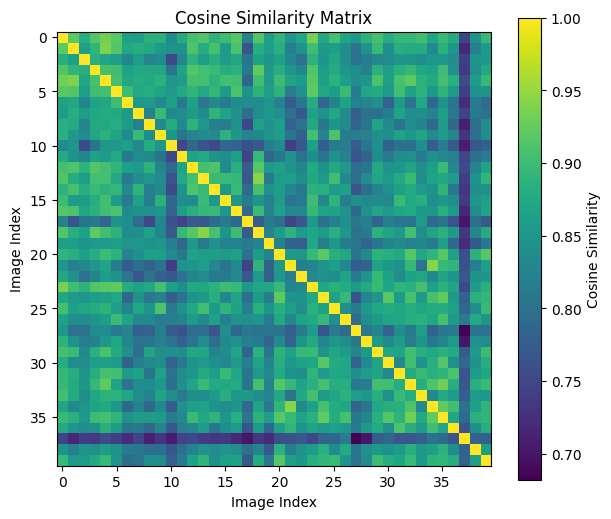

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
plt.imshow(sim_matrix)
plt.colorbar(label="Cosine Similarity")
plt.title("Cosine Similarity Matrix")
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.show()

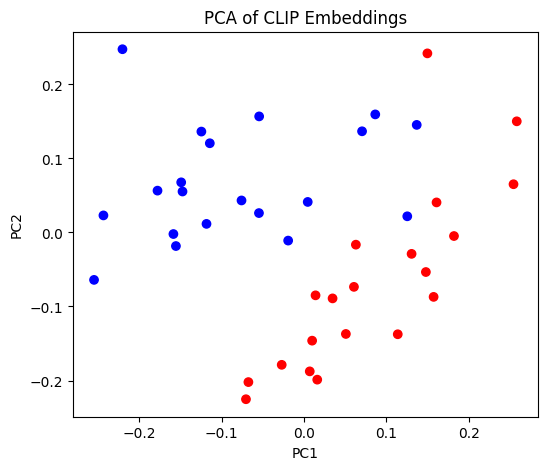

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

labels = metadata["label"].tolist()
colors = ["red" if l == "cat" else "blue" for l in labels]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=colors)
plt.title("PCA of CLIP Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [19]:
embeddings = np.load("outputs/clip_embeddings_cat_dog.npy")
metadata = pd.read_csv("outputs/clip_metadata_cat_dog.csv")

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)
labels = metadata["label"].tolist()

In [20]:
same_class_sims = []
diff_class_sims = []

n = len(labels)

for i in range(n):
    for j in range(i + 1, n):
        if labels[i] == labels[j]:
            same_class_sims.append(sim_matrix[i, j])
        else:
            diff_class_sims.append(sim_matrix[i, j])

same_class_sims = np.array(same_class_sims)
diff_class_sims = np.array(diff_class_sims)

print("same-class pairs:", len(same_class_sims))
print("different-class pairs:", len(diff_class_sims))

same-class pairs: 380
different-class pairs: 400


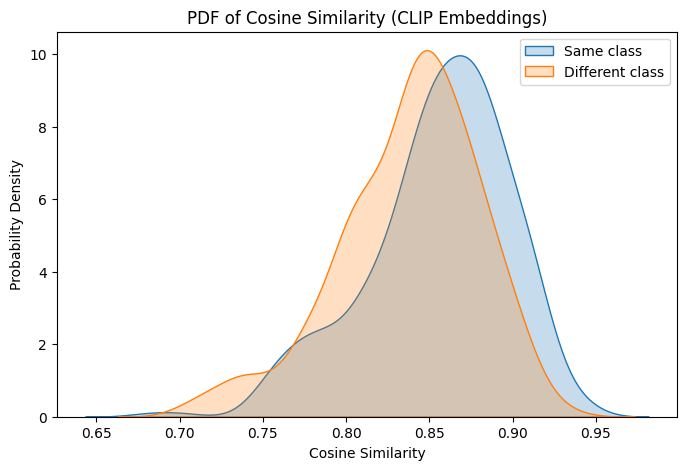

In [23]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.kdeplot(same_class_sims, label="Same class", fill=True)
sns.kdeplot(diff_class_sims, label="Different class", fill=True)

plt.xlabel("Cosine Similarity")
plt.ylabel("Probability Density")
plt.title("PDF of Cosine Similarity (CLIP Embeddings)")
plt.legend()
plt.show()

In [24]:
all_sims_full = sim_matrix.flatten()

print("Total values:", len(all_sims_full))
print(all_sims_full[:10])

Total values: 1600
[0.9999996  0.91940266 0.88270515 0.9154826  0.93291354 0.9186212
 0.86401474 0.8595223  0.883416   0.88390607]


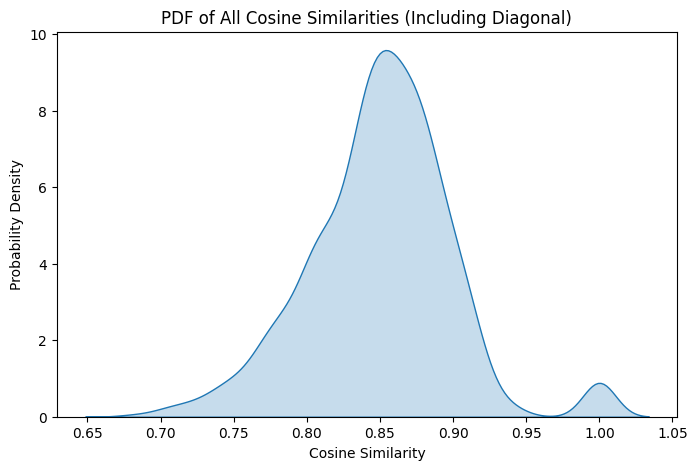

In [25]:
plt.figure(figsize=(8,5))

sns.kdeplot(all_sims_full, fill=True)

plt.xlabel("Cosine Similarity")
plt.ylabel("Probability Density")
plt.title("PDF of All Cosine Similarities (Including Diagonal)")

plt.show()

In [26]:
n = sim_matrix.shape[0]

# 去重（上三角）
upper_tri_indices = np.triu_indices(n, k=1)
all_sims = sim_matrix[upper_tri_indices]

# 修正数值误差
all_sims = np.clip(all_sims, -1, 1)

print(all_sims.max(), all_sims.min())

0.9427948 0.6821607


<Axes: ylabel='Density'>

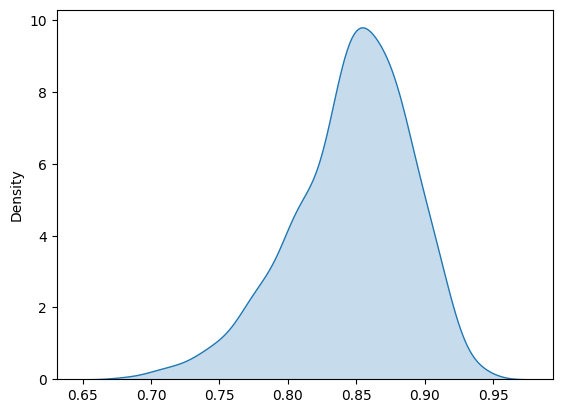

In [27]:
sns.kdeplot(all_sims, fill=True)

In [28]:

labels = metadata["label"].tolist()

cat_indices = [i for i, l in enumerate(labels) if l == "cat"]
dog_indices = [i for i, l in enumerate(labels) if l == "dog"]

cat_cat_sims = []
dog_dog_sims = []

# cat-cat
for i in range(len(cat_indices)):
    for j in range(i + 1, len(cat_indices)):
        idx_i = cat_indices[i]
        idx_j = cat_indices[j]
        cat_cat_sims.append(sim_matrix[idx_i, idx_j])

# dog-dog
for i in range(len(dog_indices)):
    for j in range(i + 1, len(dog_indices)):
        idx_i = dog_indices[i]
        idx_j = dog_indices[j]
        dog_dog_sims.append(sim_matrix[idx_i, idx_j])

cat_cat_sims = np.array(cat_cat_sims)
dog_dog_sims = np.array(dog_dog_sims)

# clip 一下，避免数值精度误差
cat_cat_sims = np.clip(cat_cat_sims, -1, 1)
dog_dog_sims = np.clip(dog_dog_sims, -1, 1)

print("cat-cat pairs:", len(cat_cat_sims))
print("dog-dog pairs:", len(dog_dog_sims))
print("cat-cat mean:", cat_cat_sims.mean())
print("dog-dog mean:", dog_dog_sims.mean())

cat-cat pairs: 190
dog-dog pairs: 190
cat-cat mean: 0.85662603
dog-dog mean: 0.85387975


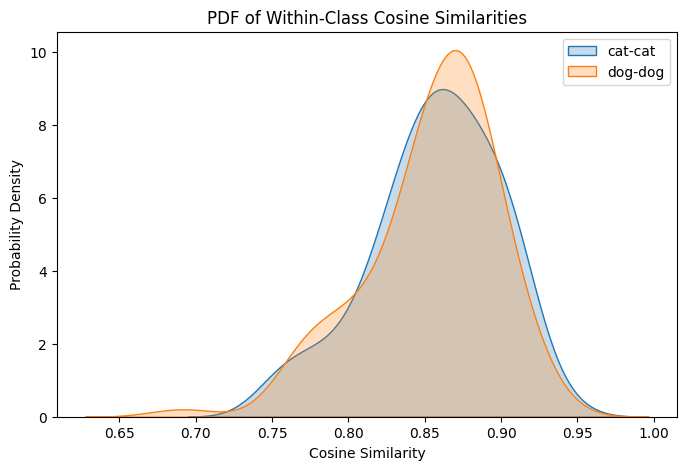

In [29]:
plt.figure(figsize=(8, 5))

sns.kdeplot(cat_cat_sims, fill=True, label="cat-cat", bw_adjust=1.2)
sns.kdeplot(dog_dog_sims, fill=True, label="dog-dog", bw_adjust=1.2)

plt.xlabel("Cosine Similarity")
plt.ylabel("Probability Density")
plt.title("PDF of Within-Class Cosine Similarities")
plt.legend()
plt.show()